In [21]:
import msprime
import matplotlib.pyplot as plt
import concurrent.futures as cf
import numpy as np
import demesdraw
from scipy import stats
from statsmodels.stats.multitest import multipletests


In [22]:
seq_len = 23513712
recomb_rate = 2.40463e-08
sample_size = 20

In [23]:
def mean_sq_error(sfs, theoritical_sfs):
    assert len(sfs) == len(theoritical_sfs)
    return np.sqrt(np.mean([(sfs[i]-theoritical_sfs[i])**2 for i in range(len(sfs))]))

## Fixed population size

pop_size = 1000

In [ ]:
pop_size = 10000
simulation_replicates = 10000

n_samples: 20
theta: 40000.000000
oriented: 1
seed: -1
outfile: example_sfs.blk
noised: 0
parameters: 0.000000 1.000000 
Temps d'exécution : 0.0003590000 secondes


<BarContainer object of 19 artists>

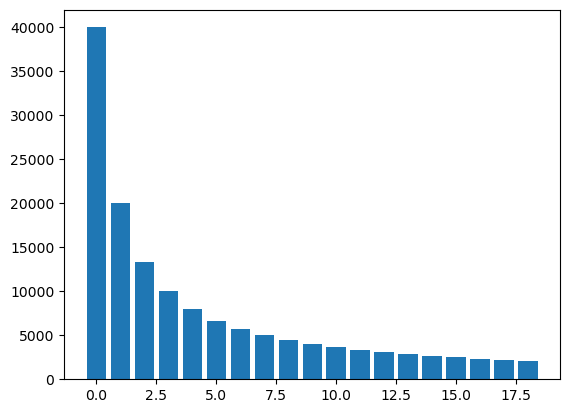

In [25]:
theata = 4 * pop_size 
!.././bin/blockbuster_simulator -n {sample_size} -t {theata} -p 0,1 -o example_sfs.blk -f 1 -e 0
with open("example_sfs.blk", "r") as f:
    theoritical_sfs = f.read().strip().split(" ")
!rm example_sfs.blk
theoritical_sfs = [float(x) for x in theoritical_sfs]
plt.bar(range(len(theoritical_sfs)), theoritical_sfs)


In [26]:
shorter_seq_len = seq_len#int(seq_len / 10)
def simulate_sfs(model):

    ts = msprime.sim_ancestry(
        samples=sample_size,
        sequence_length=shorter_seq_len,
        recombination_rate=recomb_rate,
        ploidy=1,
        population_size=pop_size,
        model=model
    )

    sfs = ts.allele_frequency_spectrum(
        polarised=True,
        span_normalise=True,
        mode="branch"
    )[1:-1]
    return sfs


def parallel_simulation(model, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        sfss = list(executor.map(simulate_sfs, [model]*simulation_replicates))
    return sfss

def parallel_errors(sfss, theoritical_sfs, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(mean_sq_error, sfss, [theoritical_sfs]*len(sfss)))
    return errors
#for model in msprime.SmcKApproxCoalescent(hull_offset=1), msprime.StandardCoalescent()]:
sfss_smc = parallel_simulation(msprime.SmcKApproxCoalescent(hull_offset=1), max_workers=16)
errors_smc = np.array(parallel_errors(sfss_smc, theoritical_sfs, max_workers=16))
mean_error_smc = np.mean(errors_smc/(sum(theoritical_sfs)))
print("Mean relative error SMC: ", mean_error_smc)

sfss_hudson = parallel_simulation(msprime.StandardCoalescent(), max_workers=16)
error_hudson = np.array(parallel_errors(sfss_hudson, theoritical_sfs, max_workers=16))
mean_error_hudson = np.mean(error_hudson/(sum(theoritical_sfs)))
print("Mean relative error Hudson: ", mean_error_hudson)

Mean relative error SMC:  0.040822372275433415
Mean relative error Hudson:  0.040842134023019665


#### t_test on errors

In [27]:
t_stat, p = stats.ttest_ind(errors_smc, error_hudson)
print(f"T-test SMC vs Hudson (p_value): {p}")

T-test SMC vs Hudson (p_value): 0.04645040714302532


#### t_test on each sfs bin

In [28]:
p_vals = []
for i in range(len(sfss_smc[0])):
    smc_vals = [sfss_smc[j][i] for j in range(len(sfss_smc))]
    hudson_vals = [sfss_hudson[j][i] for j in range(len(sfss_hudson))]
    t_stat, p_val = stats.ttest_ind(smc_vals, hudson_vals)
    p_vals.append(p_val)
    
reject, p_corrected, _, _ = multipletests(p_vals, method="bonferroni", alpha=0.05)

for i in range(len(reject)):
    
    print(f"SFS bin {i+1}: reject null hypothesis: {reject[i]}, p_value: {p_vals[i]}, p_value corrected: {p_corrected[i]}")

SFS bin 1: reject null hypothesis: False, p_value: 0.044732939118117925, p_value corrected: 0.8499258432442406
SFS bin 2: reject null hypothesis: False, p_value: 0.6472275720991029, p_value corrected: 1.0
SFS bin 3: reject null hypothesis: False, p_value: 0.1497764161985444, p_value corrected: 1.0
SFS bin 4: reject null hypothesis: False, p_value: 0.2830654192962554, p_value corrected: 1.0
SFS bin 5: reject null hypothesis: False, p_value: 0.48970025800494743, p_value corrected: 1.0
SFS bin 6: reject null hypothesis: False, p_value: 0.45546794063752616, p_value corrected: 1.0
SFS bin 7: reject null hypothesis: False, p_value: 0.15019275586379388, p_value corrected: 1.0
SFS bin 8: reject null hypothesis: False, p_value: 0.3359298229465113, p_value corrected: 1.0
SFS bin 9: reject null hypothesis: False, p_value: 0.9914516107116507, p_value corrected: 1.0
SFS bin 10: reject null hypothesis: False, p_value: 0.9778067001087876, p_value corrected: 1.0
SFS bin 11: reject null hypothesis: Fal

## Two steps model

## expansion

In [29]:
pop_recent = 10000
pop_ancient = 1000
time_point = 10000

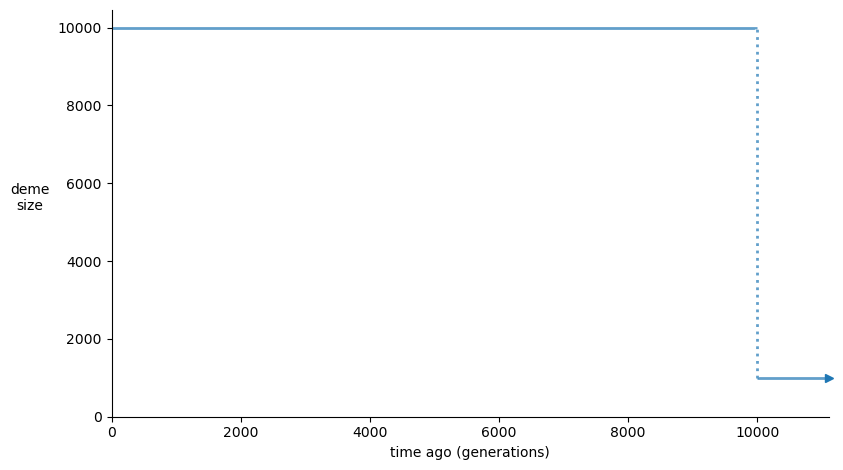

In [30]:
demography = msprime.Demography()
demography.add_population(name="pop0", initial_size=pop_recent)
demography.add_population_parameters_change(
    time=time_point,
    population="pop0",
    initial_size=pop_ancient
)
graph = msprime.Demography.to_demes(demography)
demesdraw.size_history(graph)
plt.show()

n_samples: 20
theta: 40000.000000
oriented: 1
seed: -1
outfile: example_sfs.blk
noised: 0
parameters: 1.000000 0.100000 
Temps d'exécution : 0.0003980000 secondes


<BarContainer object of 19 artists>

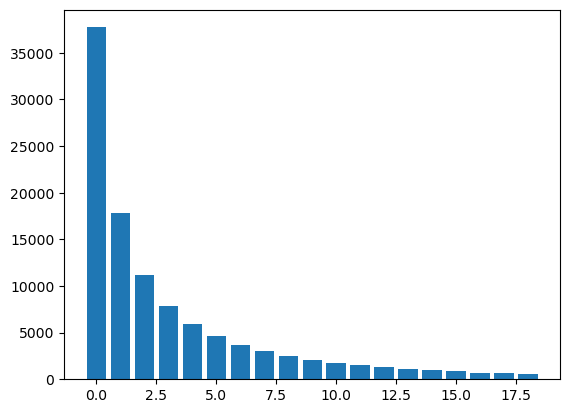

In [31]:
theata_recent = 4 * pop_recent 
time_ne = time_point/pop_recent
relative_size = pop_ancient/pop_recent

!.././bin/blockbuster_simulator -n 20 -t {theata_recent} -p {time_ne},{relative_size} -o example_sfs.blk -f 1 -e 0
with open("example_sfs.blk", "r") as f:
    theoritical_sfs_2 = f.read().strip().split(" ")
!rm example_sfs.blk
theoritical_sfs_2 = [float(x) for x in theoritical_sfs_2]
plt.bar(range(len(theoritical_sfs_2)), theoritical_sfs_2)

In [32]:
shorter_seq_len = seq_len#int(seq_len / 10)
def simulate_sfs(model):

    ts = msprime.sim_ancestry(
        samples=sample_size,
        demography=demography,
        sequence_length=shorter_seq_len,
        recombination_rate=recomb_rate,
        ploidy=1,
        model=model
    )

    sfs = ts.allele_frequency_spectrum(
        polarised=True,
        span_normalise=True,
        mode="branch"
    )[1:-1]
    return sfs


def parallel_simulation(model, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        sfss = list(executor.map(simulate_sfs, [model]*simulation_replicates))
    return sfss

def parallel_errors(sfss, theoritical_sfs_2, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(mean_sq_error, sfss, [theoritical_sfs_2]*len(sfss)))
    return errors
#for model in msprime.SmcKApproxCoalescent(hull_offset=1), msprime.StandardCoalescent()]:
sfss_smc_2_e = parallel_simulation(msprime.SmcKApproxCoalescent(hull_offset=1), max_workers=16)
errors_smc_2_e = np.array(parallel_errors(sfss_smc_2_e, theoritical_sfs_2, max_workers=16))
mean_error_smc_2_e = np.mean(errors_smc_2_e/(sum(theoritical_sfs_2)))
print("Mean relative error SMC: ", mean_error_smc_2_e)

sfss_hudson_2_e = parallel_simulation(msprime.StandardCoalescent(), max_workers=16)
error_hudson_2_e = np.array(parallel_errors(sfss_hudson_2_e, theoritical_sfs_2, max_workers=16))
mean_error_hudson_2_e = np.mean(error_hudson_2_e/(sum(theoritical_sfs_2)))
print("Mean relative error Hudson: ", mean_error_hudson_2_e)

Mean relative error SMC:  0.04879207981728887
Mean relative error Hudson:  0.04878067222707968


#### t_test on errors

In [33]:
t_stat, p = stats.ttest_ind(errors_smc_2_e, error_hudson_2_e)
print(f"T-test SMC vs Hudson (p_value): {p}")

T-test SMC vs Hudson (p_value): 0.3855344642299623


#### t_test on each sfs bin

In [34]:
p_vals = []
for i in range(len(sfss_smc_2_e[0])):
    smc_vals = [sfss_smc_2_e[j][i] for j in range(len(sfss_smc_2_e))]
    hudson_vals = [sfss_hudson_2_e[j][i] for j in range(len(sfss_hudson_2_e))]
    t_stat, p_val = stats.ttest_ind(smc_vals, hudson_vals)
    p_vals.append(p_val)
    
reject, p_corrected, _, _ = multipletests(p_vals, method="bonferroni", alpha=0.05)

for i in range(len(reject)):
    
    print(f"SFS bin {i+1}: reject null hypothesis: {reject[i]}, p_value: {p_vals[i]}, p_value corrected: {p_corrected[i]}")

SFS bin 1: reject null hypothesis: False, p_value: 0.4028318144339009, p_value corrected: 1.0
SFS bin 2: reject null hypothesis: False, p_value: 0.9322610220536681, p_value corrected: 1.0
SFS bin 3: reject null hypothesis: False, p_value: 0.8160368678616916, p_value corrected: 1.0
SFS bin 4: reject null hypothesis: False, p_value: 0.37739359280588824, p_value corrected: 1.0
SFS bin 5: reject null hypothesis: False, p_value: 0.24122608362080178, p_value corrected: 1.0
SFS bin 6: reject null hypothesis: False, p_value: 0.18758264381310738, p_value corrected: 1.0
SFS bin 7: reject null hypothesis: False, p_value: 0.8365826920276312, p_value corrected: 1.0
SFS bin 8: reject null hypothesis: False, p_value: 0.5731657639087246, p_value corrected: 1.0
SFS bin 9: reject null hypothesis: False, p_value: 0.9618413848903753, p_value corrected: 1.0
SFS bin 10: reject null hypothesis: False, p_value: 0.925358459673786, p_value corrected: 1.0
SFS bin 11: reject null hypothesis: False, p_value: 0.979

## contraction

In [35]:
pop_ancient = 10000
pop_recent = 1000
time_point = 10000

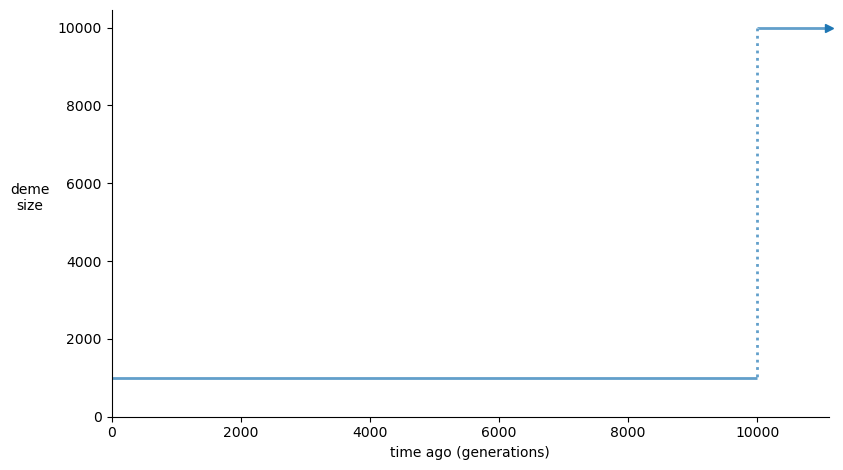

In [36]:
demography = msprime.Demography()
demography.add_population(name="pop0", initial_size=pop_recent)
demography.add_population_parameters_change(
    time=time_point,
    population="pop0",
    initial_size=pop_ancient
)
graph = msprime.Demography.to_demes(demography)
demesdraw.size_history(graph)
plt.show()

n_samples: 20
theta: 4000.000000
oriented: 1
seed: -1
outfile: example_sfs.blk
noised: 0
parameters: 10.000000 10.000000 
Temps d'exécution : 0.0003890000 secondes


<BarContainer object of 19 artists>

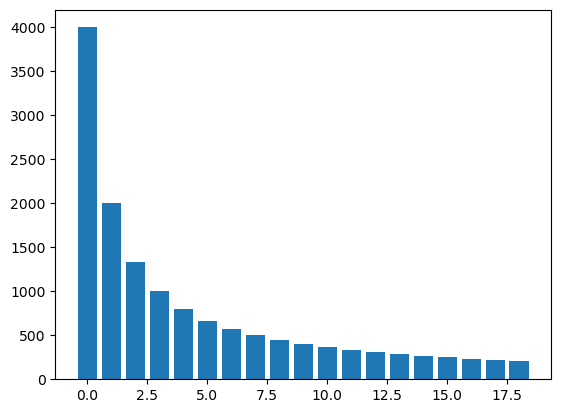

In [37]:
theata_recent = 4 * pop_recent 
time_ne = time_point/pop_recent
relative_size = pop_ancient/pop_recent

!.././bin/blockbuster_simulator -n 20 -t {theata_recent} -p {time_ne},{relative_size} -o example_sfs.blk -f 1 -e 0
with open("example_sfs.blk", "r") as f:
    theoritical_sfs_3 = f.read().strip().split(" ")
!rm example_sfs.blk
theoritical_sfs_3 = [float(x) for x in theoritical_sfs_3]
plt.bar(range(len(theoritical_sfs_3)), theoritical_sfs_3)

In [38]:
shorter_seq_len = seq_len#int(seq_len / 10)
def simulate_sfs(model):

    ts = msprime.sim_ancestry(
        samples=sample_size,
        demography=demography,
        sequence_length=shorter_seq_len,
        recombination_rate=recomb_rate,
        ploidy=1,
        model=model
    )

    sfs = ts.allele_frequency_spectrum(
        polarised=True,
        span_normalise=True,
        mode="branch"
    )[1:-1]
    return sfs


def parallel_simulation(model, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        sfss = list(executor.map(simulate_sfs, [model]*simulation_replicates))
    return sfss

def parallel_errors(sfss, theoritical_sfs_2, max_workers=4):
    with cf.ProcessPoolExecutor(max_workers=max_workers) as executor:
        errors = list(executor.map(mean_sq_error, sfss, [theoritical_sfs_2]*len(sfss)))
    return errors
#for model in msprime.SmcKApproxCoalescent(hull_offset=1), msprime.StandardCoalescent()]:
sfss_smc_2_c = parallel_simulation(msprime.SmcKApproxCoalescent(hull_offset=1), max_workers=16)
errors_smc_2_c = np.array(parallel_errors(sfss_smc_2_c, theoritical_sfs_2, max_workers=16))
mean_error_smc_2_c = np.mean(errors_smc_2_c/(sum(theoritical_sfs_2)))
print("Mean relative error SMC: ", mean_error_smc_2_c)

sfss_hudson_2_c = parallel_simulation(msprime.StandardCoalescent(), max_workers=16)
error_hudson_2_c = np.array(parallel_errors(sfss_hudson_2_c, theoritical_sfs_2, max_workers=16))
mean_error_hudson_2_c = np.mean(error_hudson_2_c/(sum(theoritical_sfs_2)))
print("Mean relative error Hudson: ", mean_error_hudson_2_c)

Mean relative error SMC:  0.09214851240481768
Mean relative error Hudson:  0.09215250085622438


#### t_test on errors

In [39]:
t_stat, p = stats.ttest_ind(errors_smc_2_c, error_hudson_2_c)
print(f"T-test SMC vs Hudson (p_value): {p}")

T-test SMC vs Hudson (p_value): 0.28314046358311373


#### t_test on each sfs bin

In [40]:
p_vals = []
for i in range(len(sfss_smc_2_c[0])):
    smc_vals = [sfss_smc_2_c[j][i] for j in range(len(sfss_smc_2_c))]
    hudson_vals = [sfss_hudson_2_c[j][i] for j in range(len(sfss_hudson_2_c))]
    t_stat, p_val = stats.ttest_ind(smc_vals, hudson_vals)
    p_vals.append(p_val)
    
reject, p_corrected, _, _ = multipletests(p_vals, method="bonferroni", alpha=0.05)

for i in range(len(reject)):
    
    print(f"SFS bin {i+1}: reject null hypothesis: {reject[i]}, p_value: {p_vals[i]}, p_value corrected: {p_corrected[i]}")

SFS bin 1: reject null hypothesis: False, p_value: 0.2735124833369311, p_value corrected: 1.0
SFS bin 2: reject null hypothesis: False, p_value: 0.7781574564151266, p_value corrected: 1.0
SFS bin 3: reject null hypothesis: False, p_value: 0.44918134429005907, p_value corrected: 1.0
SFS bin 4: reject null hypothesis: False, p_value: 0.3566580632043662, p_value corrected: 1.0
SFS bin 5: reject null hypothesis: False, p_value: 0.5164182574267806, p_value corrected: 1.0
SFS bin 6: reject null hypothesis: False, p_value: 0.4362291148352334, p_value corrected: 1.0
SFS bin 7: reject null hypothesis: False, p_value: 0.7992558838552185, p_value corrected: 1.0
SFS bin 8: reject null hypothesis: False, p_value: 0.7666993158686788, p_value corrected: 1.0
SFS bin 9: reject null hypothesis: False, p_value: 0.32094136230379966, p_value corrected: 1.0
SFS bin 10: reject null hypothesis: False, p_value: 0.9592940957576009, p_value corrected: 1.0
SFS bin 11: reject null hypothesis: False, p_value: 0.580